True vacuum:
phi_true = -2.102227081872952
v_true = 39478411.61521384

False vacuum:
phi_false = 1.8544549209071597
v_false = 39478415.511461474

Barrier top:
phi_top = 0.2477721609657927
v_top = 39478417.724916115

Delta_v = 2.2134546414017677
B = 4.4269092828035355
Gamma = 0.011951370956357975


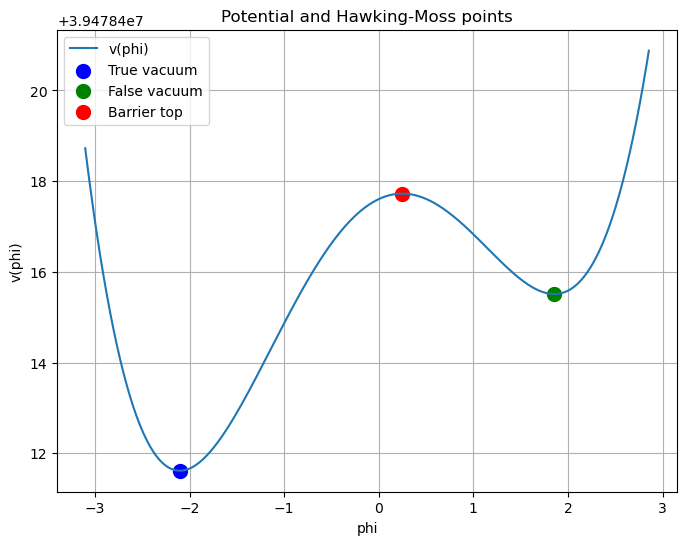

In [1]:

#HM with Stochastic#
import numpy as np
import math
import matplotlib.pyplot as plt

# ------------------------
# PARAMETERS
# ------------------------
alpha = 0.2
beta = 2.2
Mpl = 1.0
H = 1e-3 * Mpl

# ------------------------
# DEFINE Omega
# ------------------------
def Omega(alpha, beta):
    return 1.0 + alpha + math.sqrt(beta)

# ------------------------
# DEFINE POTENTIAL
# ------------------------
def v(phi, alpha, beta, H, Mpl):
    Om = Omega(alpha, beta)
    V0 = 4 * math.pi**2 * Mpl**2 / H**2
    shape = (math.pi**2)/(3*Om) * (
        4*alpha*phi
        - (2*beta/Om)*phi**2
        + (4/Om**3)*phi**4
    )
    return V0 + shape

# ------------------------
# FIRST DERIVATIVE ROOTS
# ------------------------
def find_extrema(alpha, beta):
    Om = Omega(alpha, beta)
    p = -(beta * Om**2) / 4.0
    q =  (alpha * Om**3) / 4.0
    roots = np.roots([1.0, 0.0, p, q])
    real_roots = sorted([r.real for r in roots if abs(r.imag) < 1e-10])
    return real_roots

# ------------------------
# SECOND DERIVATIVE
# ------------------------
def d2v(phi, alpha, beta):
    Om = Omega(alpha, beta)
    return (math.pi**2)/(3*Om) * (-4*beta/Om + 48*phi**2/Om**3)

# ------------------------
# FIND TRUE, FALSE, BARRIER
# ------------------------
roots = find_extrema(alpha, beta)

mins = []
maxs = []

for r in roots:
    if d2v(r, alpha, beta) > 0:
        mins.append(r)
    else:
        maxs.append(r)

# classify minima
vmins = [(x, v(x, alpha, beta, H, Mpl)) for x in mins]
vmins_sorted = sorted(vmins, key=lambda t: t[1])

phi_true, v_true = vmins_sorted[0]
phi_false, v_false = vmins_sorted[1]

# barrier between minima
lo, hi = sorted([phi_true, phi_false])
phi_top = [x for x in maxs if lo < x < hi][0]
v_top = v(phi_top, alpha, beta, H, Mpl)

# ------------------------
# HM EXPONENT AND RATE
# ------------------------
Delta_v = v_top - v_false
B = 2 * Delta_v
Gamma = math.exp(-B)

# ------------------------
# PRINT RESULTS
# ------------------------
print("True vacuum:")
print("phi_true =", phi_true)
print("v_true =", v_true)

print("\nFalse vacuum:")
print("phi_false =", phi_false)
print("v_false =", v_false)

print("\nBarrier top:")
print("phi_top =", phi_top)
print("v_top =", v_top)

print("\nDelta_v =", Delta_v)
print("B =", B)
print("Gamma =", Gamma)

# ------------------------
# PLOT POTENTIAL
# ------------------------
phi_plot = np.linspace(min(roots)-1, max(roots)+1, 1000)
v_plot = [v(p, alpha, beta, H, Mpl) for p in phi_plot]

plt.figure(figsize=(8,6))
plt.plot(phi_plot, v_plot, label="v(phi)")

plt.scatter(phi_true, v_true, color='blue', s=100, label="True vacuum")
plt.scatter(phi_false, v_false, color='green', s=100, label="False vacuum")
plt.scatter(phi_top, v_top, color='red', s=100, label="Barrier top")

plt.xlabel("phi")
plt.ylabel("v(phi)")
plt.title("Potential and Hawking-Moss points")
plt.legend()
plt.grid(True)
plt.show()


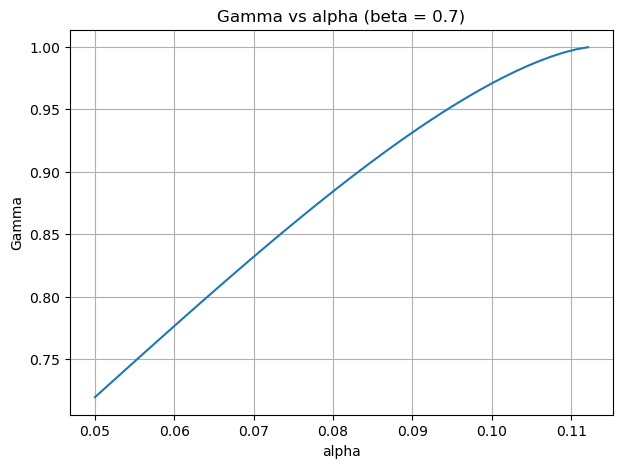

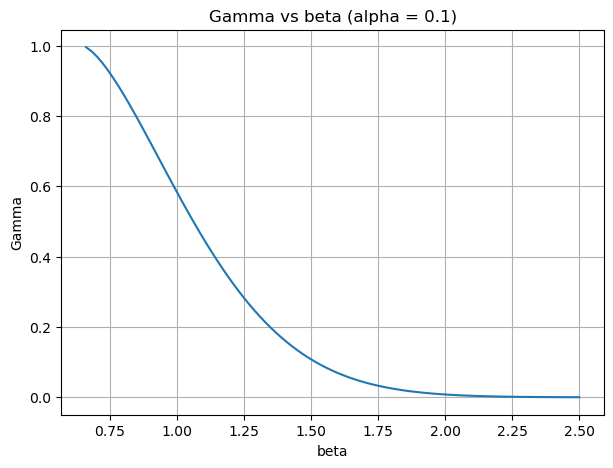

In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt

# ------------------------
# REUSE SAME FUNCTIONS
# ------------------------

def Omega(alpha, beta):
    return 1.0 + alpha + math.sqrt(beta)

def v(phi, alpha, beta, H=1e-3, Mpl=1.0):
    Om = Omega(alpha, beta)
    V0 = 4 * math.pi**2 * Mpl**2 / H**2
    shape = (math.pi**2)/(3*Om) * (
        4*alpha*phi
        - (2*beta/Om)*phi**2
        + (4/Om**3)*phi**4
    )
    return V0 + shape

def d2v(phi, alpha, beta):
    Om = Omega(alpha, beta)
    return (math.pi**2)/(3*Om) * (-4*beta/Om + 48*phi**2/Om**3)

def find_extrema(alpha, beta):
    Om = Omega(alpha, beta)
    p = -(beta * Om**2) / 4.0
    q =  (alpha * Om**3) / 4.0
    roots = np.roots([1.0, 0.0, p, q])
    real_roots = sorted([r.real for r in roots if abs(r.imag) < 1e-10])
    return real_roots

def compute_Gamma(alpha, beta, H=1e-3, Mpl=1.0):

    roots = find_extrema(alpha, beta)
    if len(roots) < 3:
        return np.nan

    mins = []
    maxs = []

    for r in roots:
        if d2v(r, alpha, beta) > 0:
            mins.append(r)
        else:
            maxs.append(r)

    if len(mins) < 2:
        return np.nan

    vmins = [(x, v(x, alpha, beta, H, Mpl)) for x in mins]
    vmins_sorted = sorted(vmins, key=lambda t: t[1])

    phi_true, v_true = vmins_sorted[0]
    phi_false, v_false = vmins_sorted[1]

    lo, hi = sorted([phi_true, phi_false])

    candidates = [x for x in maxs if lo < x < hi]
    if len(candidates) == 0:
        return np.nan

    phi_top = candidates[0]
    v_top = v(phi_top, alpha, beta, H, Mpl)

    Delta_v = v_top - v_false
    B = 2 * Delta_v
    Gamma = math.exp(-B)

    return Gamma


# ============================================================
# 1) Gamma vs alpha (fixed beta=0.7)
# ============================================================

beta_fixed = 0.7
alpha_vals = np.linspace(0.05, 0.2, 100)
Gamma_alpha = [compute_Gamma(a, beta_fixed) for a in alpha_vals]

plt.figure(figsize=(7,5))
plt.plot(alpha_vals, Gamma_alpha)
plt.xlabel("alpha")
plt.ylabel("Gamma")
plt.title("Gamma vs alpha (beta = 0.7)")
plt.grid(True)
plt.show()


# ============================================================
# 2) Gamma vs beta (fixed alpha=0.1)
# ============================================================

alpha_fixed = 0.1
beta_vals = np.linspace(0.5, 2.5, 100)
Gamma_beta = [compute_Gamma(alpha_fixed, b) for b in beta_vals]

plt.figure(figsize=(7,5))
plt.plot(beta_vals, Gamma_beta)
plt.xlabel("beta")
plt.ylabel("Gamma")
plt.title("Gamma vs beta (alpha = 0.1)")
plt.grid(True)
plt.show()


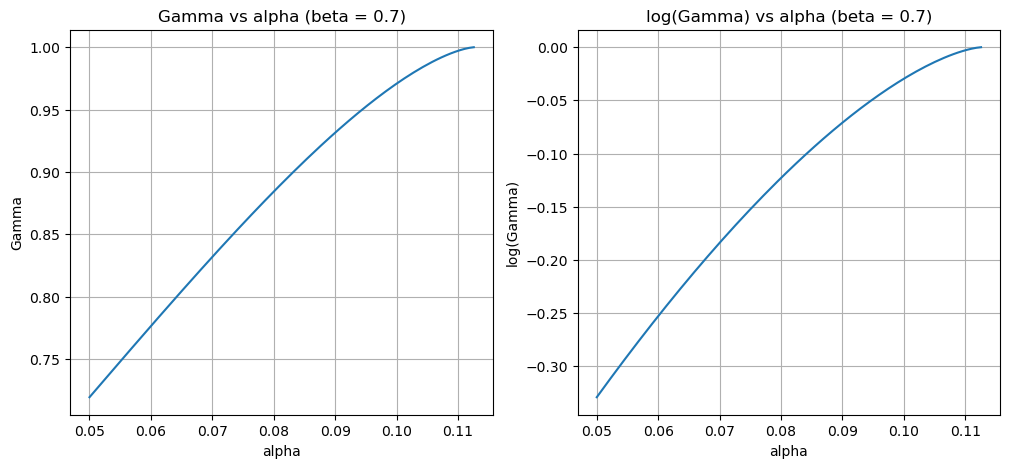

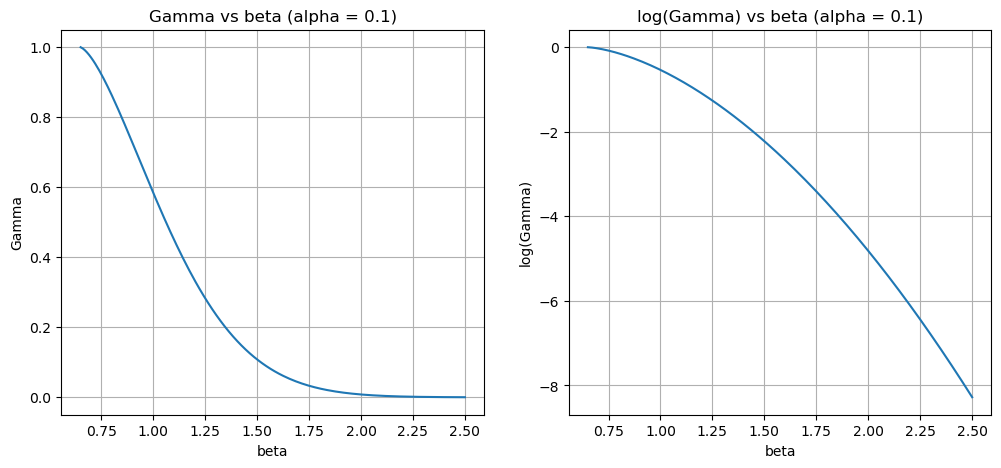

In [3]:
import numpy as np
import math
import matplotlib.pyplot as plt

# ------------------------
# FUNCTIONS (same as before)
# ------------------------

def Omega(alpha, beta):
    return 1.0 + alpha + math.sqrt(beta)

def v(phi, alpha, beta, H=1e-3, Mpl=1.0):
    Om = Omega(alpha, beta)
    V0 = 4 * math.pi**2 * Mpl**2 / H**2
    shape = (math.pi**2)/(3*Om) * (
        4*alpha*phi
        - (2*beta/Om)*phi**2
        + (4/Om**3)*phi**4
    )
    return V0 + shape

def d2v(phi, alpha, beta):
    Om = Omega(alpha, beta)
    return (math.pi**2)/(3*Om) * (-4*beta/Om + 48*phi**2/Om**3)

def find_extrema(alpha, beta):
    Om = Omega(alpha, beta)
    p = -(beta * Om**2) / 4.0
    q =  (alpha * Om**3) / 4.0
    roots = np.roots([1.0, 0.0, p, q])
    real_roots = sorted([r.real for r in roots if abs(r.imag) < 1e-10])
    return real_roots

def compute_Gamma(alpha, beta, H=1e-3, Mpl=1.0):

    roots = find_extrema(alpha, beta)
    if len(roots) < 3:
        return np.nan

    mins = []
    maxs = []

    for r in roots:
        if d2v(r, alpha, beta) > 0:
            mins.append(r)
        else:
            maxs.append(r)

    if len(mins) < 2:
        return np.nan

    vmins = [(x, v(x, alpha, beta, H, Mpl)) for x in mins]
    vmins_sorted = sorted(vmins, key=lambda t: t[1])

    phi_true, v_true = vmins_sorted[0]
    phi_false, v_false = vmins_sorted[1]

    lo, hi = sorted([phi_true, phi_false])
    candidates = [x for x in maxs if lo < x < hi]

    if len(candidates) == 0:
        return np.nan

    phi_top = candidates[0]
    v_top = v(phi_top, alpha, beta, H, Mpl)

    Delta_v = v_top - v_false
    B = 2 * Delta_v
    Gamma = math.exp(-B)

    return Gamma


# ============================================================
# 1) Gamma and log(Gamma) vs alpha
# ============================================================

beta_fixed = 0.7
alpha_vals = np.linspace(0.05, 0.2, 200)

Gamma_alpha = np.array([compute_Gamma(a, beta_fixed) for a in alpha_vals])
logGamma_alpha = np.log(Gamma_alpha)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(alpha_vals, Gamma_alpha)
plt.xlabel("alpha")
plt.ylabel("Gamma")
plt.title("Gamma vs alpha (beta = 0.7)")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(alpha_vals, logGamma_alpha)
plt.xlabel("alpha")
plt.ylabel("log(Gamma)")
plt.title("log(Gamma) vs alpha (beta = 0.7)")
plt.grid(True)

plt.show()


# ============================================================
# 2) Gamma and log(Gamma) vs beta
# ============================================================

alpha_fixed = 0.1
beta_vals = np.linspace(0.5, 2.5, 200)

Gamma_beta = np.array([compute_Gamma(alpha_fixed, b) for b in beta_vals])
logGamma_beta = np.log(Gamma_beta)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(beta_vals, Gamma_beta)
plt.xlabel("beta")
plt.ylabel("Gamma")
plt.title("Gamma vs beta (alpha = 0.1)")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(beta_vals, logGamma_beta)
plt.xlabel("beta")
plt.ylabel("log(Gamma)")
plt.title("log(Gamma) vs beta (alpha = 0.1)")
plt.grid(True)

plt.show()


<>:138: SyntaxWarning: invalid escape sequence '\L'
<>:141: SyntaxWarning: invalid escape sequence '\G'
<>:172: SyntaxWarning: invalid escape sequence '\L'
<>:175: SyntaxWarning: invalid escape sequence '\G'
<>:138: SyntaxWarning: invalid escape sequence '\L'
<>:141: SyntaxWarning: invalid escape sequence '\G'
<>:172: SyntaxWarning: invalid escape sequence '\L'
<>:175: SyntaxWarning: invalid escape sequence '\G'
/tmp/ipykernel_3778745/3801308869.py:138: SyntaxWarning: invalid escape sequence '\L'
  lw=2, label="Stochastic  $\Lambda_1/H$")
/tmp/ipykernel_3778745/3801308869.py:141: SyntaxWarning: invalid escape sequence '\G'
  lw=2, label="Hawking-Moss  $\Gamma$")
/tmp/ipykernel_3778745/3801308869.py:172: SyntaxWarning: invalid escape sequence '\L'
  lw=2, label="Stochastic  $\Lambda_1/H$")
/tmp/ipykernel_3778745/3801308869.py:175: SyntaxWarning: invalid escape sequence '\G'
  lw=2, label="Hawking-Moss  $\Gamma$")


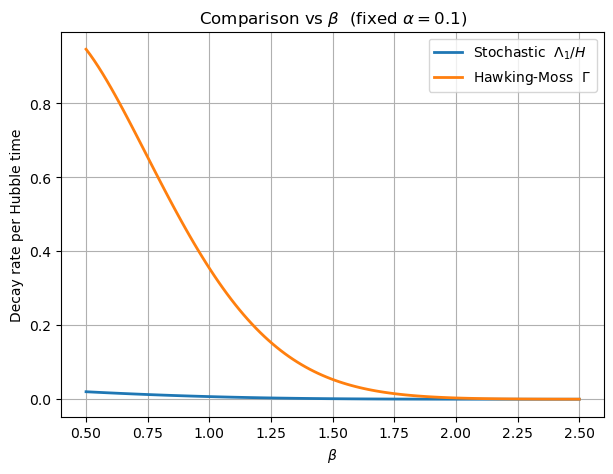

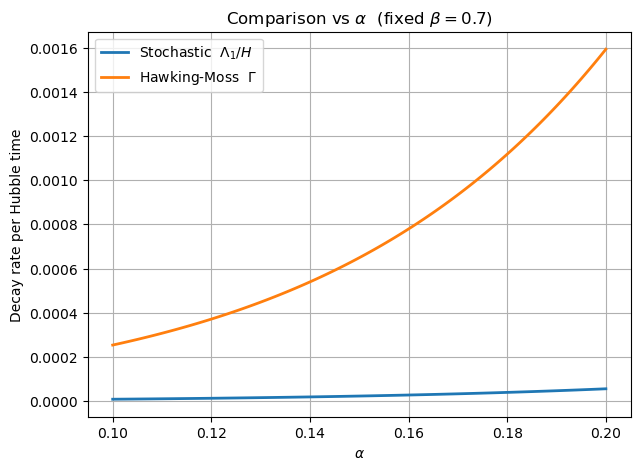

In [11]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh

# ============================================================
# PARAMETERS
# ============================================================

lambda_val = 0.05

N = 4001
L = 8
phi_vals = np.linspace(-L, L, N)
dphi = phi_vals[1] - phi_vals[0]

main_diag = np.full(N, -2.0)
off_diag = np.ones(N-1)
laplacian = diags([off_diag, main_diag, off_diag], [-1,0,1]) / dphi**2
T = -0.5 * laplacian


# ============================================================
# STOCHASTIC FUNCTIONS
# ============================================================

def Omega(alpha, beta):
    return 1 + alpha + np.sqrt(beta)

def v(phi, alpha, beta):
    Om = Omega(alpha, beta)
    return (np.pi**2/(3*Om))*(4*alpha*phi - 2*(beta/Om)*phi**2 + (4/Om**3)*phi**4)

def W(phi, alpha, beta):
    Om = Omega(alpha, beta)
    v1 = (np.pi**2/(3*Om))*(4*alpha - 4*(beta/Om)*phi + (16/Om**3)*phi**3)
    v2 = (np.pi**2/(3*Om))*(-4*(beta/Om) + (48/Om**3)*phi**2)
    return 0.5*(v1**2 - v2)


def Lambda1_over_H(alpha, beta):

    Om = Omega(alpha, beta)
    scale = np.sqrt(lambda_val) * Om**2

    W_vals = W(phi_vals, alpha, beta)
    V = diags(W_vals, 0)

    H_op = scale*(T + V)

    E_vals, _ = eigsh(H_op, k=3, sigma=0.0, which='LM')
    E_vals = np.sort(E_vals)

    return E_vals[1]/(4*np.pi**2)


# ============================================================
# HAWKING-MOSS FUNCTION (CORRECT)
# ============================================================

def find_extrema(alpha, beta):

    Om = Omega(alpha, beta)

    p = -(beta * Om**2) / 4
    q =  (alpha * Om**3) / 4

    roots = np.roots([1,0,p,q])
    roots = [r.real for r in roots if abs(r.imag)<1e-10]

    return sorted(roots)


def Gamma_HM(alpha, beta):

    roots = find_extrema(alpha, beta)

    if len(roots) < 3:
        return np.nan

    Om = Omega(alpha, beta)

    def v_full(phi):
        V0 = 4*np.pi**2/(1e-3)**2
        return V0 + (np.pi**2/(3*Om))*(4*alpha*phi
               -2*(beta/Om)*phi**2 + (4/Om**3)*phi**4)

    def d2v(phi):
        return (np.pi**2/(3*Om))*(-4*beta/Om + 48*phi**2/Om**3)

    mins = []
    maxs = []

    for r in roots:
        if d2v(r) > 0:
            mins.append(r)
        else:
            maxs.append(r)

    if len(mins)<2:
        return np.nan

    vmins = [(x,v_full(x)) for x in mins]
    vmins.sort(key=lambda x:x[1])

    phi_false = vmins[1][0]

    phi_top = [x for x in maxs if min(mins)<x<max(mins)][0]

    Delta_v = v_full(phi_top) - v_full(phi_false)

    B = 2*Delta_v

    return np.exp(-B)


# ============================================================
# COMPARISON 1: fixed alpha, scan beta
# ============================================================

alpha_fixed = 0.05

beta_vals = np.linspace(0.5, 2.5, 120)

Lambda_vals = []
Gamma_vals = []

for beta in beta_vals:

    Lambda_vals.append(Lambda1_over_H(alpha_fixed, beta))
    Gamma_vals.append(Gamma_HM(alpha_fixed, beta))


plt.figure(figsize=(7,5))

plt.plot(beta_vals, Lambda_vals,
         lw=2, label="Stochastic  $\Lambda_1/H$")

plt.plot(beta_vals, Gamma_vals,
         lw=2, label="Hawking-Moss  $\Gamma$")

plt.xlabel(r"$\beta$")
plt.ylabel("Decay rate per Hubble time")
plt.title(r"Comparison vs $\beta$  (fixed $\alpha=0.1$)")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# COMPARISON 2: fixed beta, scan alpha
# ============================================================

beta_fixed = 2.5

alpha_vals = np.linspace(0.1, 0.2, 120)

Lambda_vals = []
Gamma_vals = []

for alpha in alpha_vals:

    Lambda_vals.append(Lambda1_over_H(alpha, beta_fixed))
    Gamma_vals.append(Gamma_HM(alpha, beta_fixed))


plt.figure(figsize=(7,5))

plt.plot(alpha_vals, Lambda_vals,
         lw=2, label="Stochastic  $\Lambda_1/H$")

plt.plot(alpha_vals, Gamma_vals,
         lw=2, label="Hawking-Moss  $\Gamma$")

plt.xlabel(r"$\alpha$")
plt.ylabel("Decay rate per Hubble time")
plt.title(r"Comparison vs $\alpha$  (fixed $\beta=0.7$)")
plt.legend()
plt.grid(True)

plt.show()


<>:154: SyntaxWarning: invalid escape sequence '\L'
<>:155: SyntaxWarning: invalid escape sequence '\G'
<>:188: SyntaxWarning: invalid escape sequence '\L'
<>:189: SyntaxWarning: invalid escape sequence '\G'
<>:154: SyntaxWarning: invalid escape sequence '\L'
<>:155: SyntaxWarning: invalid escape sequence '\G'
<>:188: SyntaxWarning: invalid escape sequence '\L'
<>:189: SyntaxWarning: invalid escape sequence '\G'
/tmp/ipykernel_3778745/3538382320.py:154: SyntaxWarning: invalid escape sequence '\L'
  ax.plot(beta_vals, Lambda_vals, lw=2, label="Stochastic  $\Lambda_1/H$")
/tmp/ipykernel_3778745/3538382320.py:155: SyntaxWarning: invalid escape sequence '\G'
  ax.plot(beta_vals, Gamma_vals, lw=2, label="Hawking-Moss  $\Gamma$")
/tmp/ipykernel_3778745/3538382320.py:188: SyntaxWarning: invalid escape sequence '\L'
  ax.plot(alpha_vals, Lambda_vals, lw=2, label="Stochastic  $\Lambda_1/H$")
/tmp/ipykernel_3778745/3538382320.py:189: SyntaxWarning: invalid escape sequence '\G'
  ax.plot(alpha_va

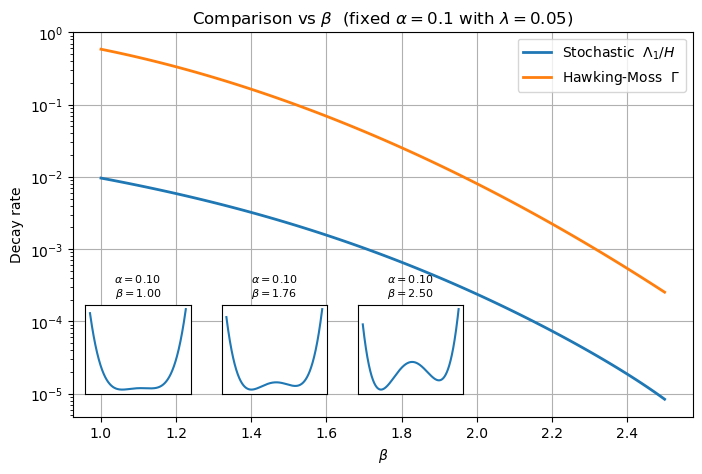

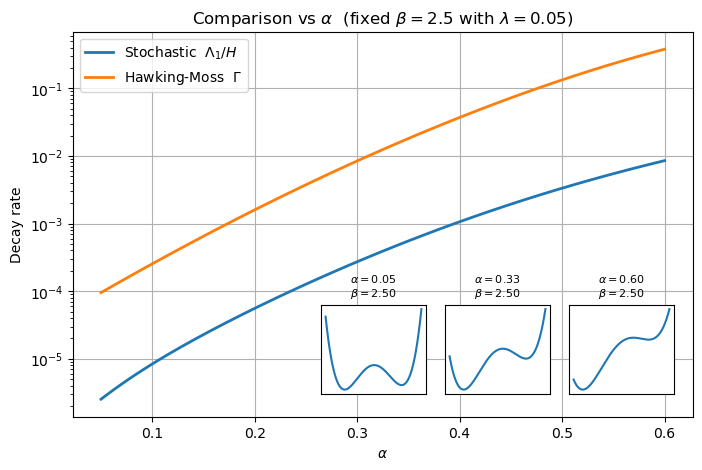

In [117]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh

# ============================================================
# PARAMETERS
# ============================================================

lambda_val = 0.05

N = 4001
L = 8
phi_vals = np.linspace(-L, L, N)
dphi = phi_vals[1] - phi_vals[0]

main_diag = np.full(N, -2.0)
off_diag = np.ones(N-1)
laplacian = diags([off_diag, main_diag, off_diag], [-1,0,1]) / dphi**2
T = -0.5 * laplacian


# ============================================================
# FUNCTIONS
# ============================================================

def Omega(alpha, beta):
    return 1 + alpha + np.sqrt(beta)

def v_shape(phi, alpha, beta):
    Om = Omega(alpha, beta)
    return (np.pi**2/(3*Om))*(4*alpha*phi - 2*(beta/Om)*phi**2 + (4/Om**3)*phi**4)

def W(phi, alpha, beta):
    Om = Omega(alpha, beta)
    v1 = (np.pi**2/(3*Om))*(4*alpha - 4*(beta/Om)*phi + (16/Om**3)*phi**3)
    v2 = (np.pi**2/(3*Om))*(-4*(beta/Om) + (48/Om**3)*phi**2)
    return 0.5*(v1**2 - v2)


def Lambda1_over_H(alpha, beta):

    Om = Omega(alpha, beta)
    scale = np.sqrt(lambda_val) * Om**2

    W_vals = W(phi_vals, alpha, beta)
    V = diags(W_vals, 0)

    H_op = scale*(T + V)

    E_vals, _ = eigsh(H_op, k=3, sigma=0.0, which='LM')
    E_vals = np.sort(E_vals)

    return E_vals[1]/(4*np.pi**2)


def find_extrema(alpha, beta):

    Om = Omega(alpha, beta)

    p = -(beta * Om**2) / 4
    q =  (alpha * Om**3) / 4

    roots = np.roots([1,0,p,q])
    roots = [r.real for r in roots if abs(r.imag)<1e-10]

    return sorted(roots)


def Gamma_HM(alpha, beta):

    roots = find_extrema(alpha, beta)
    if len(roots) < 3:
        return np.nan

    Om = Omega(alpha, beta)

    def v_full(phi):
        V0 = 4*np.pi**2/(1e-3)**2

        return V0 + v_shape(phi, alpha, beta)

    def d2v(phi):
        return (np.pi**2/(3*Om))*(-4*beta/Om + 48*phi**2/Om**3)

    # classify extrema
    mins = sorted([r for r in roots if d2v(r) > 0])
    maxs = sorted([r for r in roots if d2v(r) < 0])

    if len(mins) < 2 or len(maxs) < 1:
        return np.nan

    # choose FV = higher minimum (metastable), TV = lower minimum (global)
    vmins = sorted([(x, v_full(x)) for x in mins], key=lambda t: t[1])
    phi_true,  v_true  = vmins[0]
    phi_false, v_false = vmins[1]  # <-- metastable false vacuum (higher v)

    # barrier top must lie between the two minima in field space
    lo, hi = sorted([phi_true, phi_false])
    candidates = [x for x in maxs if lo < x < hi]
    if len(candidates) == 0:
        return np.nan

    phi_top = candidates[0]  # should be unique for this quartic
    v_top = v_full(phi_top)

    Delta_v = v_top - v_false
    B = 2 * Delta_v
    return np.exp(-B)


# ============================================================
# HELPER: DRAW SMALL POTENTIAL INSET
# ============================================================

def draw_potential_inset(ax, alpha, beta, position):

    axins = ax.inset_axes(position)

    phi_plot = np.linspace(-3.5,3.5,500)
    v_plot = v_shape(phi_plot, alpha, beta)

    axins.plot(phi_plot, v_plot, lw=1.5)

    axins.set_xticks([])
    axins.set_yticks([])

    axins.set_title(
        rf"$\alpha={alpha:.2f}$"+"\n"+rf"$\beta={beta:.2f}$",
        fontsize=8
    )

    axins.grid(True, alpha=0.3)


# ============================================================
# PLOT 1: scan beta
# ============================================================

alpha_fixed = 0.1
beta_vals = np.linspace(1, 2.5, 120)

Lambda_vals = [Lambda1_over_H(alpha_fixed,b) for b in beta_vals]
Gamma_vals  = [Gamma_HM(alpha_fixed,b) for b in beta_vals]

beta_min = beta_vals[0]
beta_mid = beta_vals[len(beta_vals)//2]
beta_max = beta_vals[-1]


fig, ax = plt.subplots(figsize=(8,5))

ax.plot(beta_vals, Lambda_vals, lw=2, label="Stochastic  $\Lambda_1/H$")
ax.plot(beta_vals, Gamma_vals, lw=2, label="Hawking-Moss  $\Gamma$")

ax.set_xlabel(r"$\beta$")
ax.set_ylabel("Decay rate")
ax.set_title(r"Comparison vs $\beta$  (fixed $\alpha=0.1$ with $\lambda=0.05$)")
ax.legend()
ax.grid(True)

# 3 potential insets
draw_potential_inset(ax, alpha_fixed, beta_min, [0.02,0.06,0.17,0.23])
draw_potential_inset(ax, alpha_fixed, beta_mid, [0.24,0.06,0.17,0.23])
draw_potential_inset(ax, alpha_fixed, beta_max, [0.46,0.06,0.17,0.23])
plt.yscale('log')
plt.show()


# ============================================================
# PLOT 2: scan alpha
# ============================================================

beta_fixed = 2.5
alpha_vals = np.linspace(0.05, 0.6, 120)

Lambda_vals = [Lambda1_over_H(a,beta_fixed) for a in alpha_vals]
Gamma_vals  = [Gamma_HM(a,beta_fixed) for a in alpha_vals]

alpha_min = alpha_vals[0]
alpha_mid = alpha_vals[len(alpha_vals)//2]
alpha_max = alpha_vals[-1]


fig, ax = plt.subplots(figsize=(8,5))

ax.plot(alpha_vals, Lambda_vals, lw=2, label="Stochastic  $\Lambda_1/H$")
ax.plot(alpha_vals, Gamma_vals, lw=2, label="Hawking-Moss  $\Gamma$")

ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("Decay rate")
ax.set_title(r"Comparison vs $\alpha$  (fixed $\beta=2.5$ with $\lambda=0.05$)")
ax.legend()
ax.grid(True)

# 3 potential insets
draw_potential_inset(ax, alpha_min, beta_fixed, [0.40,0.060,0.17,0.23])
draw_potential_inset(ax, alpha_mid, beta_fixed, [0.60,0.060,0.17,0.23])
draw_potential_inset(ax, alpha_max, beta_fixed, [0.80,0.060,0.17,0.23])
plt.yscale('log')
plt.show()


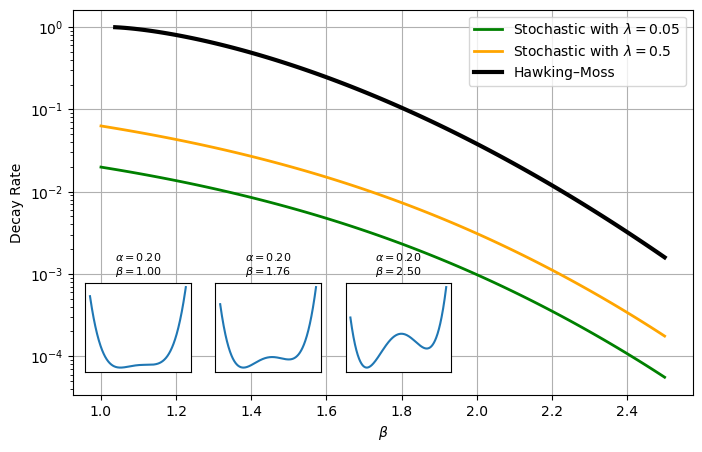

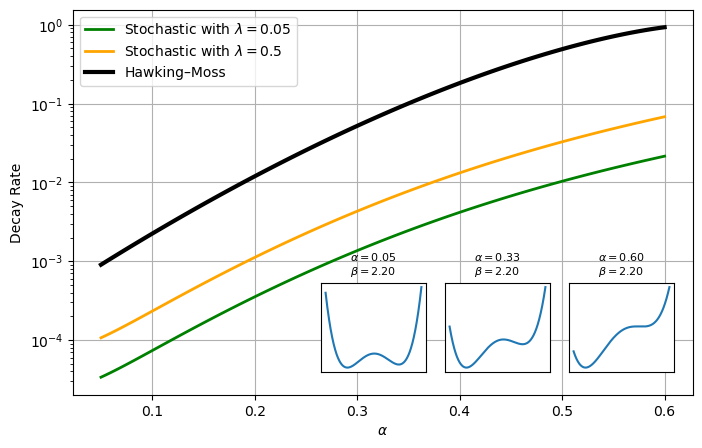

In [23]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh

# ============================================================
# GRID SETUP
# ============================================================

N = 4001
L = 8
phi_vals = np.linspace(-L, L, N)
dphi = phi_vals[1] - phi_vals[0]

main_diag = np.full(N, -2.0)
off_diag = np.ones(N-1)

laplacian = diags([off_diag, main_diag, off_diag],
                  [-1,0,1]) / dphi**2

T = -0.5 * laplacian


# ============================================================
# BASIC FUNCTIONS
# ============================================================

def Omega(alpha, beta):
    return 1 + alpha + np.sqrt(beta)


def v_shape(phi, alpha, beta):

    Om = Omega(alpha, beta)

    return (np.pi**2/(3*Om)) * (
        4*alpha*phi
        - 2*(beta/Om)*phi**2
        + (4/Om**3)*phi**4
    )


def W(phi, alpha, beta):

    Om = Omega(alpha, beta)

    v1 = (np.pi**2/(3*Om))*(
        4*alpha
        - 4*(beta/Om)*phi
        + (16/Om**3)*phi**3
    )

    v2 = (np.pi**2/(3*Om))*(
        -4*(beta/Om)
        + (48/Om**3)*phi**2
    )

    return 0.5*(v1**2 - v2)


# ============================================================
# STOCHASTIC DECAY RATE
# ============================================================

def Lambda1_over_H(alpha, beta, lambda_val):

    Om = Omega(alpha, beta)

    scale = np.sqrt(lambda_val) * Om**2

    W_vals = W(phi_vals, alpha, beta)

    V = diags(W_vals, 0)

    H_op = scale*(T + V)

    E_vals, _ = eigsh(H_op, k=3, sigma=0.0, which='LM')

    E_vals = np.sort(E_vals)

    return E_vals[1]/(4*np.pi**2)


# ============================================================
# HAWKING–MOSS DECAY RATE
# ============================================================

def find_extrema(alpha, beta):

    Om = Omega(alpha, beta)

    p = -(beta * Om**2) / 4
    q =  (alpha * Om**3) / 4

    roots = np.roots([1,0,p,q])

    roots = [r.real for r in roots if abs(r.imag)<1e-10]

    return sorted(roots)


def Gamma_HM(alpha, beta):

    roots = find_extrema(alpha, beta)

    if len(roots) < 3:
        return np.nan

    Om = Omega(alpha, beta)

    def v_full(phi):

        V0 = 4*np.pi**2/(1e-3)**2

        return V0 + v_shape(phi, alpha, beta)

    def d2v(phi):

        return (np.pi**2/(3*Om))*(
            -4*beta/Om
            + 48*phi**2/Om**3
        )

    mins = [r for r in roots if d2v(r) > 0]
    maxs = [r for r in roots if d2v(r) < 0]

    if len(mins)<2:
        return np.nan

    vmins = sorted([(x, v_full(x)) for x in mins],
                   key=lambda t:t[1])

    phi_true, v_true = vmins[0]
    phi_false, v_false = vmins[1]

    lo, hi = sorted([phi_true, phi_false])

    candidates = [x for x in maxs if lo < x < hi]

    if len(candidates)==0:
        return np.nan

    phi_top = candidates[0]

    Delta_v = v_full(phi_top) - v_false

    B = 2*Delta_v

    return np.exp(-B)


# ============================================================
# POTENTIAL INSET FUNCTION
# ============================================================
def draw_potential_inset(ax, alpha, beta, position):

    axins = ax.inset_axes(position)

    phi_plot = np.linspace(-3.5,3.5,500)

    v_plot = v_shape(phi_plot, alpha, beta)

    axins.plot(phi_plot, v_plot, lw=1.5)

    axins.set_xticks([])
    axins.set_yticks([])

    axins.set_title(
        rf"$\alpha={alpha:.2f}$"+"\n"+rf"$\beta={beta:.2f}$",
        fontsize=8
    )

    axins.grid(True, alpha=0.3)


# ============================================================
# PARAMETERS FOR COMPARISON
# ============================================================

lambdas = [0.05, 0.5]


# ============================================================
# PLOT 1: scan beta
# ============================================================

alpha_fixed = 0.2

beta_vals = np.linspace(1, 2.5, 120)

Gamma_vals = [Gamma_HM(alpha_fixed,b)
              for b in beta_vals]

fig, ax = plt.subplots(figsize=(8,5))

for lam in lambdas:

    Lambda_vals = [
        Lambda1_over_H(alpha_fixed,b,lam)
        for b in beta_vals
    ]

    ax.plot(beta_vals,
        Lambda_vals,
        lw=2,
        color='green' if lam == 0.05 else 'orange',
        label=rf"Stochastic with $\lambda={lam}$")

ax.plot(beta_vals,
        Gamma_vals,
        lw=3,
        color='black',
        label="Hawking–Moss")

ax.set_xlabel(r"$\beta$")
ax.set_ylabel("Decay Rate")
#ax.set_title(r"Comparison vs $\beta$  (fixed $\alpha=0.1$)")
ax.legend()
ax.grid(True)
ax.set_yscale('log')

# inset potentials
draw_potential_inset(ax, alpha_fixed, beta_vals[0],
                     [0.02,0.06,0.17,0.23])

draw_potential_inset(ax, alpha_fixed,
                     beta_vals[len(beta_vals)//2],
                     [0.23,0.06,0.17,0.23])

draw_potential_inset(ax, alpha_fixed,
                     beta_vals[-1],
                     [0.44,0.06,0.17,0.23])
plt.savefig("beta", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# PLOT 2: scan alpha
# ============================================================

beta_fixed = 2.2

alpha_vals = np.linspace(0.05, 0.6, 120)

Gamma_vals = [
    Gamma_HM(a,beta_fixed)
    for a in alpha_vals
]

fig, ax = plt.subplots(figsize=(8,5))

for lam in lambdas:

    Lambda_vals = [
        Lambda1_over_H(a,beta_fixed,lam)
        for a in alpha_vals
    ]

    ax.plot(alpha_vals,
        Lambda_vals,
        lw=2,
        color='green' if lam == 0.05 else 'orange',
        label=rf"Stochastic with $\lambda={lam}$")

ax.plot(alpha_vals,
        Gamma_vals,
        lw=3,
        color='black',
        label="Hawking–Moss")

ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("Decay Rate")
#ax.set_title(r"Comparison vs $\alpha$  (fixed $\beta=2.5$)")
ax.legend()
ax.grid(True)
ax.set_yscale('log')

# inset potentials
draw_potential_inset(ax,
                     alpha_vals[0],
                     beta_fixed,
                     [0.40,0.06,0.17,0.23])

draw_potential_inset(ax,
                     alpha_vals[len(alpha_vals)//2],
                     beta_fixed,
                     [0.60,0.06,0.17,0.23])

draw_potential_inset(ax,
                     alpha_vals[-1],
                     beta_fixed,
                     [0.80,0.06,0.17,0.23])
plt.savefig("alpha", dpi=300, bbox_inches="tight")
plt.show()
